<h1><center>Customer Churn Analysis</center></h1>

In [5]:
# Import libraries
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score



In [6]:
# Import dataset and view the first 5 rows.
ds = pd.read_csv('/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/my_portfolio_files/Churn_Modelling.csv')
ds.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
ds.to_csv('churn_model.csv', index = False)

<h1><center>Visualizations</center></h1>

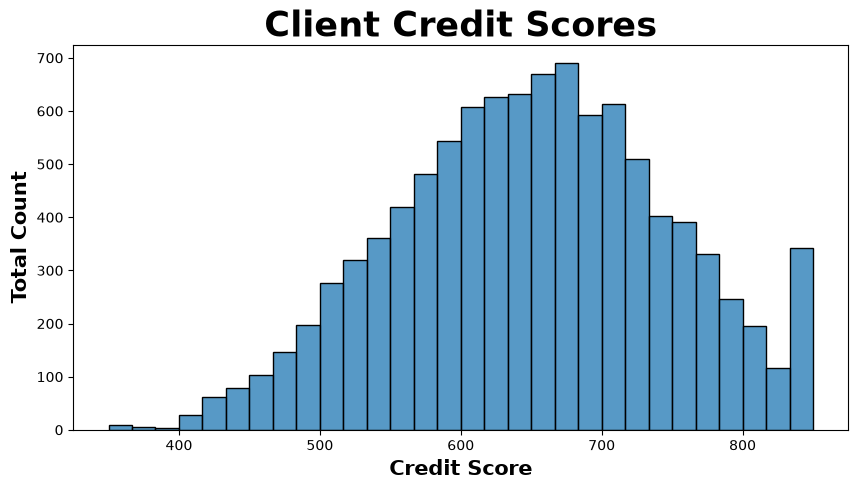

In [8]:
# Build histogram with seaborn to compare client credit scores.
plt.figure(figsize=(10, 5))
sns.histplot(data = ds, x = 'CreditScore', bins= 30)
plt.title('Client Credit Scores', fontsize = 25, weight = 'bold')
plt.xlabel('Credit Score', fontsize = 15, weight = 'bold')
plt.ylabel('Total Count', fontsize = 15, weight = 'bold')
plt.show()

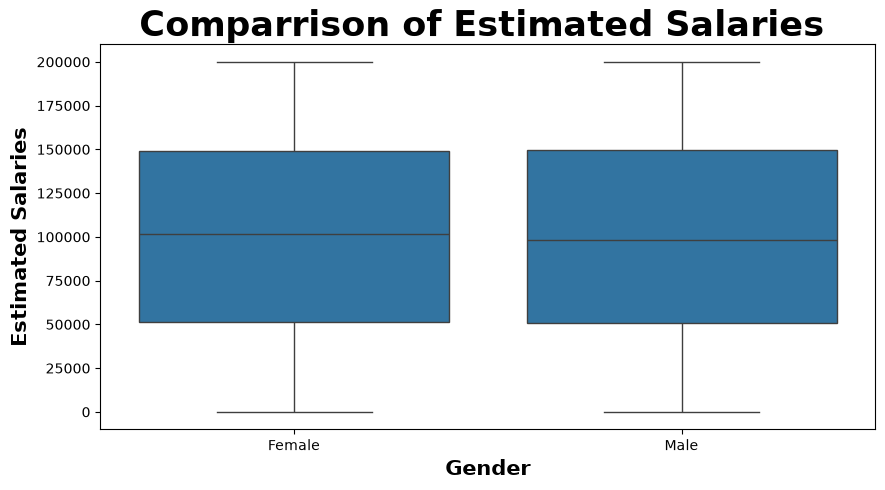

In [9]:
# Build a boxplot with seaborn to compare estimated salaries between male and female clients.
plt.figure(figsize=(10, 5))
sns.boxplot(data = ds, x = 'Gender', y = 'EstimatedSalary')
plt.title("Comparrison of Estimated Salaries ", fontsize = 25, weight = 'bold')
plt.xlabel('Gender', fontsize = 15, weight = 'bold')
plt.ylabel('Estimated Salaries', fontsize = 15, weight = 'bold')
plt.show()

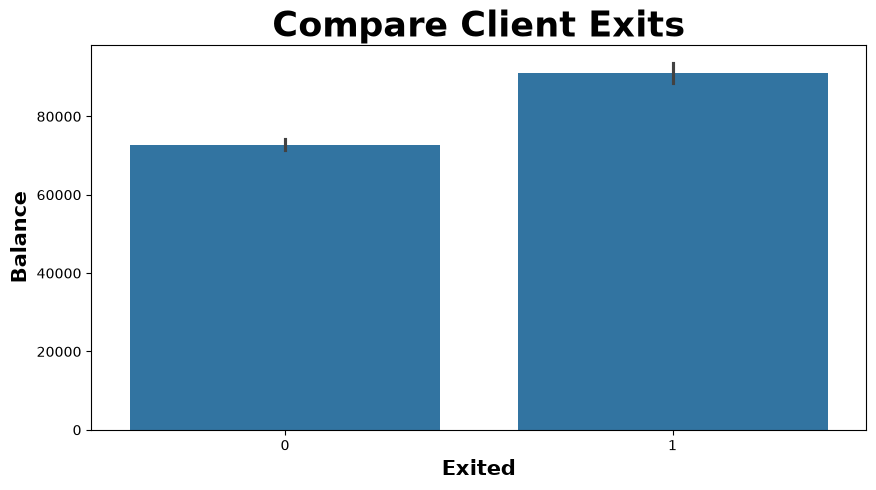

In [10]:
# Build a bar plot with seaborn to compare client exits.
plt.figure(figsize=(10,5))
sns.barplot(data = ds, x = 'Exited', y = 'Balance')
plt.title('Compare Client Exits', fontsize = 25, weight = 'bold')
plt.xlabel('Exited', fontsize = 15, weight = 'bold')
plt.ylabel('Balance', fontsize = 15, weight = 'bold')

plt.show()

<h1><center>Preprocessing Data</center></h1>

In [11]:
# Split data to X and y series
X = ds.iloc[:, 3 :-1].values
y = ds.iloc[:, -1].values

In [12]:
# View X series to ensure accuracy.
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [13]:
# View y series to ensure accuracy
print(y)

[1 0 1 ... 1 1 0]


In [14]:
# Apply label encoding to gender column.
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

In [15]:
# View data to ensure gender was recoded correctly.
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [16]:
# Apply one-hot-encoding to location column.
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))

In [17]:
# View series to ensure correct encoding.
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [18]:
# Split data into training and testing sets
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [19]:
# Apply standard scaler to X_train and X_test data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<h1><center>Create ANN</center></h1>

In [20]:
# Create artificial neural network model.
ann = tf.keras.models.Sequential()

In [21]:
# Build layers for ann model.
ann.add(tf.keras.layers.Dense(units = 6, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units = 6, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [22]:
# Fit the data to the model.
ann.fit(X_train,y_train, batch_size = 32, epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.7448 - loss: 0.5737
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step - accuracy: 0.7952 - loss: 0.4719
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step - accuracy: 0.7952 - loss: 0.4459
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.7974 - loss: 0.4327
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 312us/step - accuracy: 0.8064 - loss: 0.4228
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.8183 - loss: 0.4116
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step - accuracy: 0.8311 - loss: 0.3973
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.8411 - loss: 0.3824
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step - accuracy: 0.8450 - loss: 0.3709
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step - accuracy: 0.8486 - loss: 0.3628
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - accuracy: 0.8526 - loss: 0.3575
Epoch 12/100
250/25

In [23]:
# Test model with test set.
y_pred = ann.predict(X_test)
y_pred = (y_pred >.50)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [24]:
# View confusion matrix and accuracy score.
cm = confusion_matrix(y_test, y_pred)
print(f" The confusion matrix result is:\n {cm}")
acc = accuracy_score(y_test, y_pred)
print(f"The accuracy score is: \n {acc}")

 The confusion matrix result is:
 [[1521   74]
 [ 203  202]]
The accuracy score is: 
 0.8615


In [25]:
# Validate model with new data.
print(ann.predict(scaler.transform([[1, 0, 0, 600, 1,40, 3,60000,2, 1, 1, 50000]]))>.50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[False]]
